<!-- agrosat-cover -->
<div align="center">

<img alt="Institucion: Tec de Monterrey" src="https://img.shields.io/badge/Institucion-Tec%20de%20Monterrey-002D72">&nbsp;<img alt="Programa: MNA" src="https://img.shields.io/badge/Programa-MNA-0072CE">&nbsp;<img alt="Materia: Proyecto Integrador" src="https://img.shields.io/badge/Materia-Proyecto%20Integrador-F2A900">&nbsp;<img alt="Entregable: Avance 3" src="https://img.shields.io/badge/Entregable-Avance%203-1E40AF">

<img alt="Python: 3.12" src="https://img.shields.io/badge/Python-3.12-3776AB">&nbsp;<img alt="Jupyter: notebook" src="https://img.shields.io/badge/Jupyter-notebook-3776AB">&nbsp;<img alt="PyTorch: 2.4" src="https://img.shields.io/badge/PyTorch-2.4-3776AB">&nbsp;<img alt="Polars: 1.x" src="https://img.shields.io/badge/Polars-1.x-3776AB">

</div>

<h1 align="center">Avance 3 — Baseline tabular y reencuadre fenologico</h1>
<p align="center"><strong>AgroSatCopilot</strong> · Cuantificación de superficies de cultivo por satélite</p>

<table align="center"><tr>
<td align="center" width="200"><img src="../../img/IsaacAvila.jpg" width="130" height="130" style="border-radius:50%;object-fit:contain;background:#f0f0f0"><br><strong>Carlos Isaac Ávila Gutiérrez</strong><br><code>A01796035</code><br><sub>ML / Data Scientist</sub></td>
<td align="center" width="200"><img src="../../img/AaronBocanegra.jpg" width="130" height="130" style="border-radius:50%;object-fit:contain;background:#f0f0f0"><br><strong>Carlos Aaron Bocanegra Buitrón</strong><br><code>A01796345</code><br><sub>Full-Stack / Backend</sub></td>
<td align="center" width="200"><img src="../../img/ArthurZizumbo.png" width="130" height="130" style="border-radius:50%;object-fit:contain;background:#f0f0f0"><br><strong>Arthur Jafed Zizumbo Velasco</strong><br><code>A01796363</code><br><sub>MLOps / Platform</sub></td>
</tr></table>

---

<strong>Baseline tabular consolidado: ablation de features, descarte de leakage geografico, reencuadre fenologico y reentrenamiento de los modelos canonicos sobre el conjunto ganador.</strong>

<table>
<tr><td><strong>Equipo 17</strong></td><td>&nbsp;&nbsp;• <strong>Carlos Isaac Ávila Gutiérrez</strong> — <code>A01796035</code><br>&nbsp;&nbsp;• <strong>Carlos Aaron Bocanegra Buitrón</strong> — <code>A01796345</code><br>&nbsp;&nbsp;• <strong>Arthur Jafed Zizumbo Velasco</strong> — <code>A01796363</code></td></tr>
<tr><td><strong>Curso</strong></td><td>MNA — Tec de Monterrey · 20-abr → 3-jul-2026</td></tr>
<tr><td><strong>Sponsor académico</strong></td><td>Dr. Gerardo Jesús Camacho González · gjcamacho@tec.mx</td></tr>
<tr><td><strong>Fecha de entrega</strong></td><td>2026-05-20</td></tr>
</table>


## Resumen ejecutivo

Este cuaderno **concentra y consolida** el trabajo del Avance 3 leyendo los artefactos generados por las cinco libretas previas. No reentrena modelos: lee tablas, lee figuras, ejecuta una sola llamada a `select_winning_features` para nombrar el conjunto ganador y entrega las respuestas a las **cinco preguntas oficiales del Avance 3** con cifras consolidadas.

Las cinco preguntas oficiales son:

1. **¿Qué algoritmo se puede utilizar como baseline** para predecir las variables objetivo?
2. **¿Se puede determinar la importancia de las características** para el modelo generado? (incluir características irrelevantes afecta el rendimiento y aumenta la complejidad).
3. **¿El modelo está sub/sobreajustando** los datos de entrenamiento?
4. **¿Cuál es la métrica adecuada** para este problema de negocio?
5. **¿Cuál debería ser el desempeño mínimo** a obtener?

## Estructura

1. Las 5 preguntas oficiales y dónde se contesta cada una.
2. P1 — Tabla consolidada de los 5 modelos (3 tabulares + 2 temporales).
3. P2 — Importancia de características y bloques irrelevantes.
4. P3 — Diagnóstico sub/sobreajuste para los 5 modelos.
5. P4 — Justificación de F1-macro como métrica principal.
6. P5 — Desempeño mínimo: target 0.60, estado actual y plan.
7. Comparativa AlphaEarth vs Sentinel-2 crudo vs vector combinado.
8. Resultados FarSLIP vs RemoteCLIP.
9. Clustering fenológico sin coordenadas.
10. Tabla H-1..H-4 con decisiones consolidadas (cuatro hipótesis del Avance 3).
11. Conjunto ganador: única llamada a `select_winning_features` + manifest JSON.
12. Trazabilidad MLflow consolidada (todos los `run_id`).
13. Referencias.


In [1]:
COMPARISON_PATH_04 = "reports/baseline/04_baseline/model_comparison_04.parquet"
COMPARISON_PATH_04B = "reports/baseline/04b_baseline/model_comparison_04b.parquet"
ABLATION_BASE_PATH_04C = "reports/baseline/04c_baseline/ablation_table.parquet"
ABLATION_OPTIONAL_PATH_05 = "reports/baseline/05_reencuadre/ablation_table.parquet"
COMPARISON_TEMPORAL_PATH = "reports/baseline/05_reencuadre/model_comparison_temporal.parquet"
COMPARISON_SCENARIOS_PATH = "reports/baseline/04_baseline/comparison_alphaearth_vs_s2.csv"
FUSED_PATH = "data/features/features_fused_pastis.parquet"
WINNING_OUTPUT = "data/features/features_fused_winning_pastis.parquet"
FIGURES_SUBDIR = "us-023-preview/Avance3"
REPORTS_SUBDIR = "baseline/Avance3"
PROMOTE_THRESHOLD = 0.005
F1_TARGET = 0.60


In [2]:
from __future__ import annotations

import os
import sys
from pathlib import Path

# Bootstrap: locate the repo root by searching for pyproject.toml
_HERE = Path.cwd().resolve()
for _candidate in (_HERE, *_HERE.parents):
    if (_candidate / "pyproject.toml").is_file():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break

from ml.utils.notebook_bootstrap import setup_notebook
from IPython.display import Markdown, display

env = setup_notebook(
    figures_subdir=FIGURES_SUBDIR,
    reports_subdir=REPORTS_SUBDIR,
)
display(Markdown(env.summary_markdown()))

# Chdir to the repo root so the relative paths in the `parameters` cell
# (FEATURES_PATH = "data/...", etc.) resolve the same regardless of where
# the kernel was launched (VS Code opens with cwd = notebook folder).
# This preserves the papermill contract (parameters as relative strings) and
# avoids FileNotFoundError caused by cwd != repo root.
os.chdir(env.repo)
display(Markdown(f"**cwd anclado al repo root**: `{env.repo}`"))


| Recurso | Estado |
|---|---|
| Repo root | `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot` |
| Figures dir | `paper\figures\us-023-preview\Avance3` |
| Reports dir | `reports\baseline\Avance3` |
| Gemini API key | presente |
| Earth Engine | configurado |
| GEE project | `agrosat-copilot` |

**cwd anclado al repo root**: `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot`

## 1. Las cinco preguntas oficiales y dónde se contestan

| # | Pregunta oficial | Notebook(s) que aportan la respuesta |
|---|------------------|--------------------------------------|
| **P1** | ¿Qué algoritmo se puede utilizar como baseline? | `04_baseline` (3 tabulares + escenarios) · `04b_baseline` (piloto + cifras del baseline previo) · `04c_baseline` (qué bloques aportan) · `05_reencuadre` (5 modelos: 3 tabulares + 2 temporales sobre conjunto ganador) |
| **P2** | ¿Se puede determinar la importancia de las características? | `04_baseline` §5 (Gini, gain, SHAP, dominancia AE) · `04c_baseline` (ablación: bloques irrelevantes) · `05_reencuadre` §3 (bloques opcionales) · `04_farslip_eval` (separabilidad por espacio de embedding) |
| **P3** | ¿El modelo sub/sobreajusta? | `04_baseline` §10 (learning curves + `diagnose_fit` para RF/XGB/LGBM) · `05_reencuadre` §5.1 (loss train vs val por época + `diagnose_temporal_fit` para TempCNN/InceptionTime) |
| **P4** | ¿Cuál es la métrica adecuada? | `04_baseline` §2 (justificación F1-macro con desbalance 31×) |
| **P5** | ¿Desempeño mínimo a obtener? | `04_baseline` §3 (justificación 0.60: random vs trivial vs U-TAE PASTIS) |

In [3]:
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path
from ml.eval.reencuadre_plots import plot_optional_blocks_ablation
from ml.eval.feature_ablation import FeatureAblationResult

# Compact helper to read parquet with an explicit fallback.
def _read_or_skip(path_str: str, label: str) -> pl.DataFrame | None:
    p = Path(path_str)
    if not p.exists():
        display(Markdown(
            f'> `{label}` no encontrado en `{path_str}`. '
            'Ejecuta el notebook correspondiente antes de re-ejecutar Avance3.'
        ))
        return None
    return pl.read_parquet(p)


## 2. P1 — Algoritmo baseline: tabla consolidada de los 5 modelos

Leemos la tabla del `04_baseline.ipynb` (3 tabulares: RF, XGB, LGBM) y la del `05_reencuadre_fenologico.ipynb` (5 modelos sobre el conjunto ganador). El ranking final por F1-macro decide qué modelo promovemos como **baseline canónico** del Avance 3 y cuáles quedan como aprendices base para los ensambles del Avance 5.

In [4]:
comparison_04 = _read_or_skip(COMPARISON_PATH_04, 'model_comparison_04')
comparison_temporal = _read_or_skip(
    COMPARISON_TEMPORAL_PATH, 'model_comparison_temporal (5 modelos)'
)

if comparison_04 is not None:
    display(Markdown('**Tabla `04_baseline` — 3 modelos tabulares sobre conjunto fused completo**:'))
    display(comparison_04.sort('f1_macro', descending=True))
if comparison_temporal is not None:
    display(Markdown('**Tabla `05_reencuadre` — 5 modelos sobre conjunto ganador post-ablación**:'))
    display(comparison_temporal)
    best_row = comparison_temporal.row(0, named=True)
    display(Markdown(
        f'**Modelo ganador del Avance 3**: `{best_row["model"]}` '
        f'(familia: `{best_row["family"]}`) con F1-macro = `{best_row["f1_macro"]:.4f}`.'
    ))


**Tabla `04_baseline` — 3 modelos tabulares sobre conjunto fused completo**:

model,f1_macro,f1_weighted,miou,accuracy,cohen_kappa,train_time_s,n_features,n_samples
str,f64,f64,f64,f64,f64,f64,i64,i64
"""xgb""",0.4109,0.6919,0.3126,0.7259,0.6547,304.4,185,85951
"""lgbm""",0.3901,0.6834,0.299,0.7244,0.6495,929.7,185,85951
"""rf""",0.365,0.6583,0.2699,0.6724,0.5961,210.4,185,85951


**Tabla `05_reencuadre` — 5 modelos sobre conjunto ganador post-ablación**:

model,family,f1_macro,f1_weighted,miou,accuracy,kappa
str,str,f64,f64,f64,f64,f64
"""xgb""","""tabular""",0.433246,0.7109,0.326301,0.749229,0.684744
"""lgbm""","""tabular""",0.413067,0.70801,0.31381,0.752696,0.686812
"""rf""","""tabular""",0.383071,0.670141,0.282184,0.697025,0.623891
"""inceptiontime""","""temporal""",0.146556,0.142198,0.084999,NaN,0.109063
"""tempcnn""","""temporal""",0.111842,0.063234,0.062502,NaN,0.060915


**Modelo ganador del Avance 3**: `xgb` (familia: `tabular`) con F1-macro = `0.4332`.

## 3. P2 — Importancia de las características y bloques irrelevantes

Dos vistas complementarias:

- **Por feature individual** (gini, gain, SHAP, dominancia AlphaEarth): ver `04_baseline.ipynb` §5 + figuras `shap_summary_*.png`, `feature_importance_*.png` en `paper/figures/us-023-preview/04_baseline/`.
- **Por bloque completo** (ablación): leemos las tablas de `04c_baseline` (bloques base) y `05_reencuadre` (bloques opcionales) y graficamos el aporte agregado.

**Ablación base (`04c_baseline`)** — qué bloques del fused aportan:

feature_set,model,n_features,f1_macro,f1_weighted,miou,delta_vs_full
str,str,i64,f64,f64,f64,f64
"""full""","""xgb""",313,NaN,NaN,NaN,NaN
"""no_geom""","""xgb""",313,NaN,NaN,NaN,NaN
"""no_geom_no_era5_srtm""","""xgb""",313,NaN,NaN,NaN,NaN
"""alphaearth_only""","""xgb""",128,NaN,NaN,NaN,NaN
"""phenology_only""","""xgb""",32,NaN,NaN,NaN,NaN


**Ablación completa (`05_reencuadre`)** — con bloques opcionales:

feature_set,model,n_features,f1_macro,f1_weighted,miou,delta_vs_full
str,str,i64,f64,f64,f64,f64
"""spectral_signature_only""","""xgb""",3,NaN,NaN,NaN,NaN
"""full""","""xgb""",636,0.433246,0.7109,0.326301,NaN
"""no_geom""","""xgb""",636,0.433246,0.7109,0.326301,0.0
"""no_geom_no_era5_srtm""","""xgb""",636,0.433246,0.7109,0.326301,0.0
"""alphaearth_only""","""xgb""",64,0.352367,0.652136,0.257715,-0.080879
"""with_pheno_text""","""xgb""",416,0.287906,0.572458,0.197761,-0.14534
"""phenology_only""","""xgb""",32,0.285587,0.572341,0.196328,-0.147659
"""with_spectral_signature""","""xgb""",35,0.285587,0.572341,0.196328,-0.147659
"""pheno_text_only""","""xgb""",384,0.035496,0.197142,0.023255,-0.39775


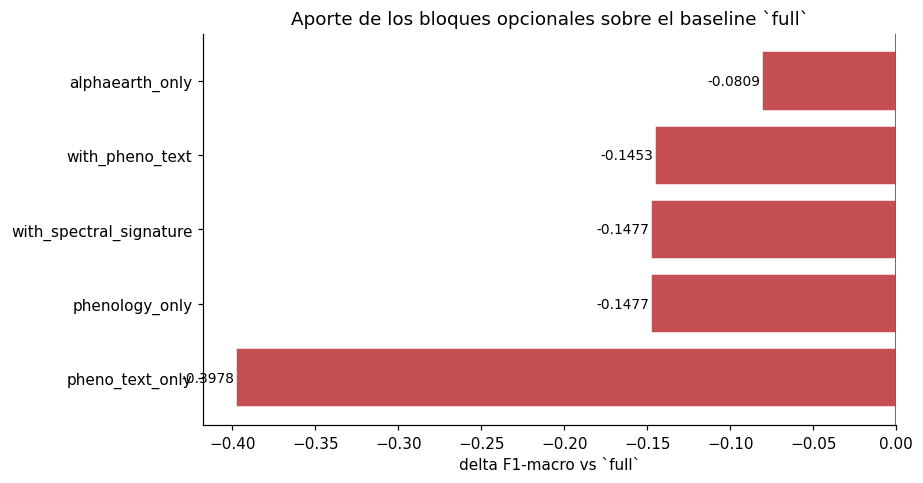

In [5]:
ablation_base = _read_or_skip(ABLATION_BASE_PATH_04C, 'ablation_table_base (04c)')
ablation_optional = _read_or_skip(ABLATION_OPTIONAL_PATH_05, 'ablation_table (05)')

if ablation_base is not None:
    display(Markdown('**Ablación base (`04c_baseline`)** — qué bloques del fused aportan:'))
    display(ablation_base.sort('f1_macro', descending=True))

if ablation_optional is not None:
    display(Markdown('**Ablación completa (`05_reencuadre`)** — con bloques opcionales:'))
    display(ablation_optional.sort('f1_macro', descending=True))
    results = [
        FeatureAblationResult(
            feature_set=row['feature_set'],
            model_kind=row['model'],
            f1_macro=row['f1_macro'] if row['f1_macro'] is not None else float('nan'),
            f1_weighted=row['f1_weighted'] if row['f1_weighted'] is not None else float('nan'),
            miou=row['miou'] if row['miou'] is not None else float('nan'),
            n_features=row['n_features'],
            delta_vs_full=row['delta_vs_full'] if row['delta_vs_full'] is not None else float('nan'),
        )
        for row in ablation_optional.iter_rows(named=True)
    ]
    fig = plot_optional_blocks_ablation(results)
    fig.savefig(env.figures_dir / 'optional_blocks.png', bbox_inches='tight')
    display(fig)
    plt.close(fig)


## 4. P3 — Sub/sobreajuste para los 5 modelos

Los 3 modelos tabulares (RF, XGB, LGBM) se diagnostican en `04_baseline.ipynb` §10 con `diagnose_fit` sobre la curva de aprendizaje clásica. Los 2 modelos temporales (TempCNN, InceptionTime) se diagnostican en `05_reencuadre.ipynb` §5.1 con `diagnose_temporal_fit` sobre el historial de train_loss/val_loss leído desde MLflow.

Aquí incrustamos las imágenes generadas por ambos cuadernos.

**Curva aprendizaje RF** — `paper/figures/us-023-preview/04_baseline/learning_curve_rf.png`:

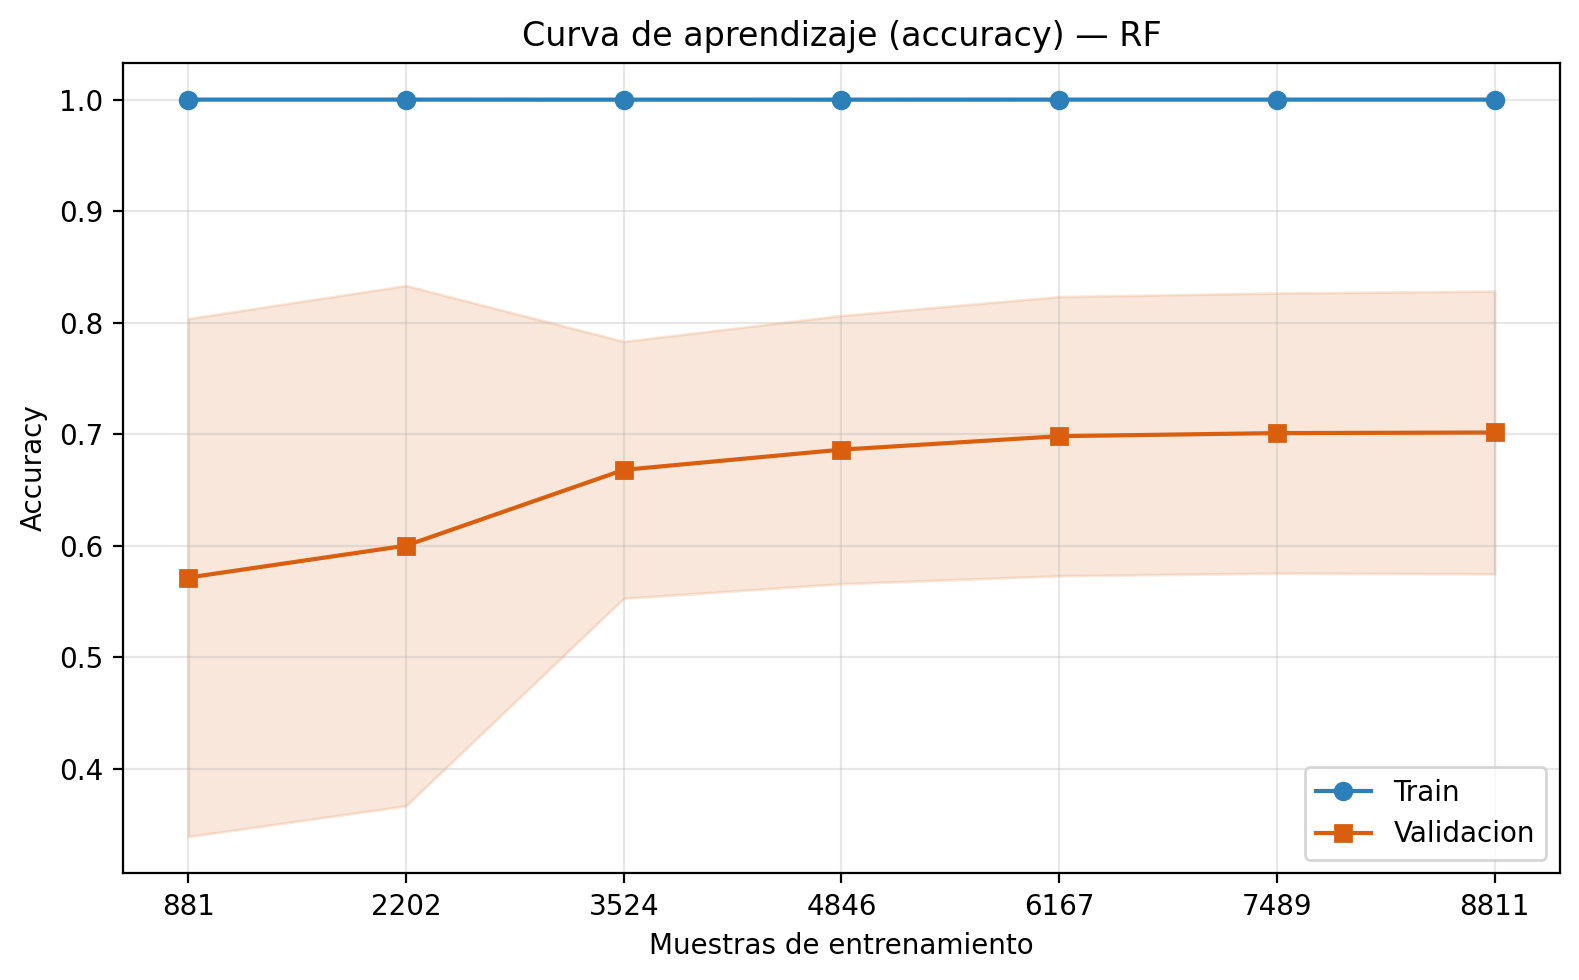

**Curva aprendizaje XGB** — `paper/figures/us-023-preview/04_baseline/learning_curve_xgb.png`:

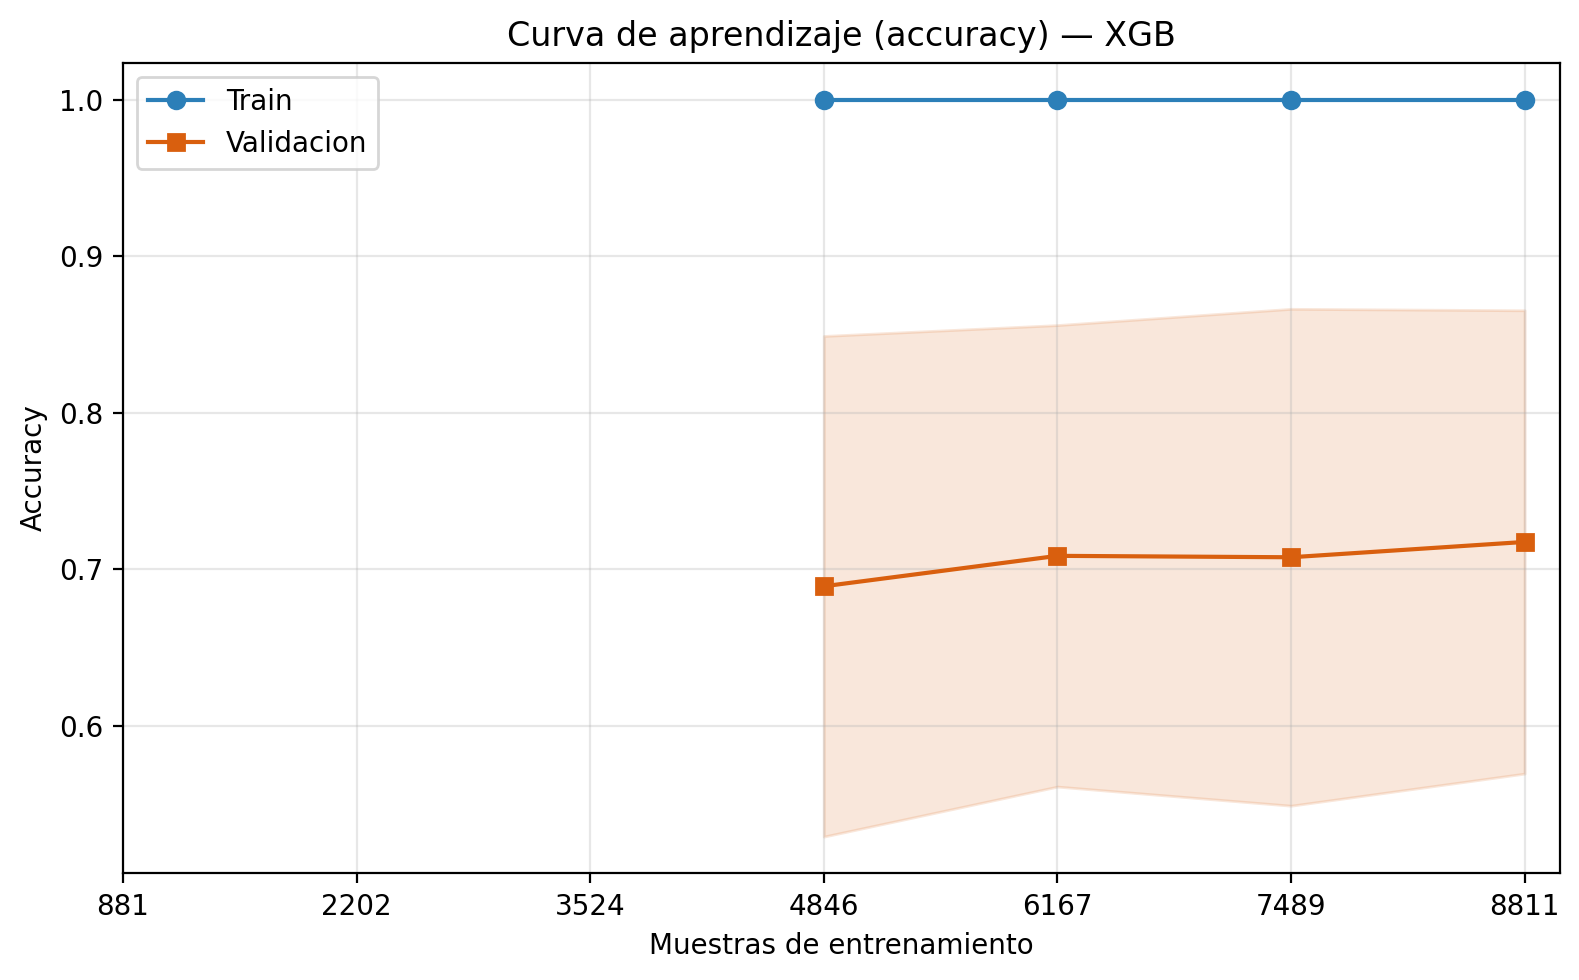

**Curva loss TempCNN** — `paper/figures/us-023-preview/05_reencuadre/loss_history_tempcnn.png`:

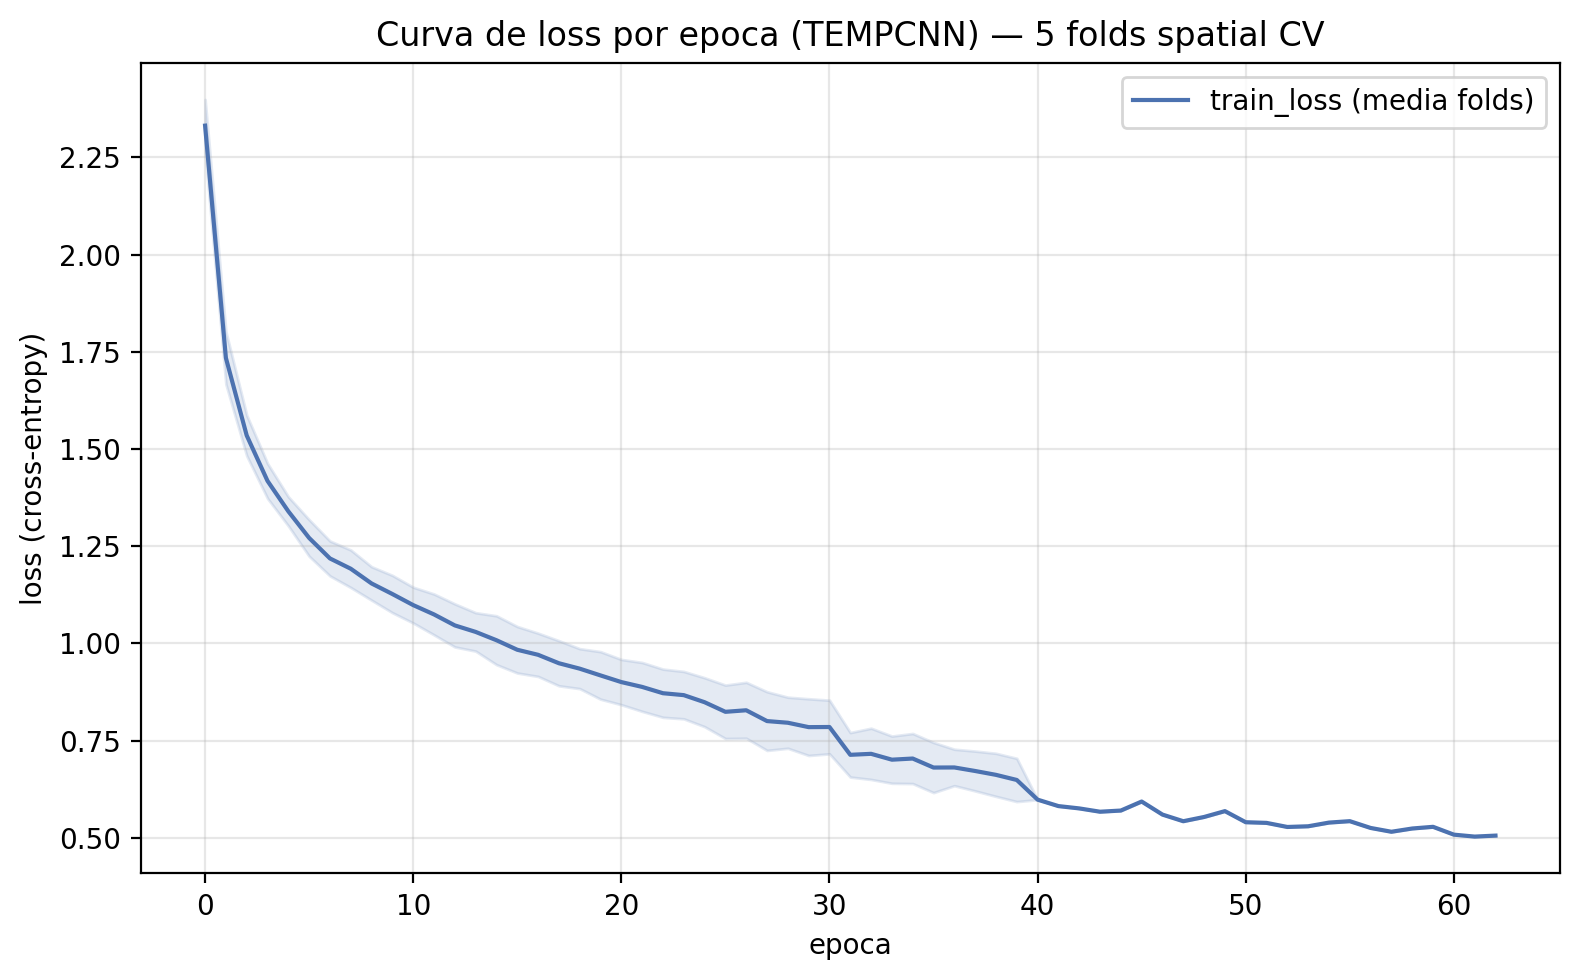

**Curva loss InceptionTime** — `paper/figures/us-023-preview/05_reencuadre/loss_history_inceptiontime.png`:

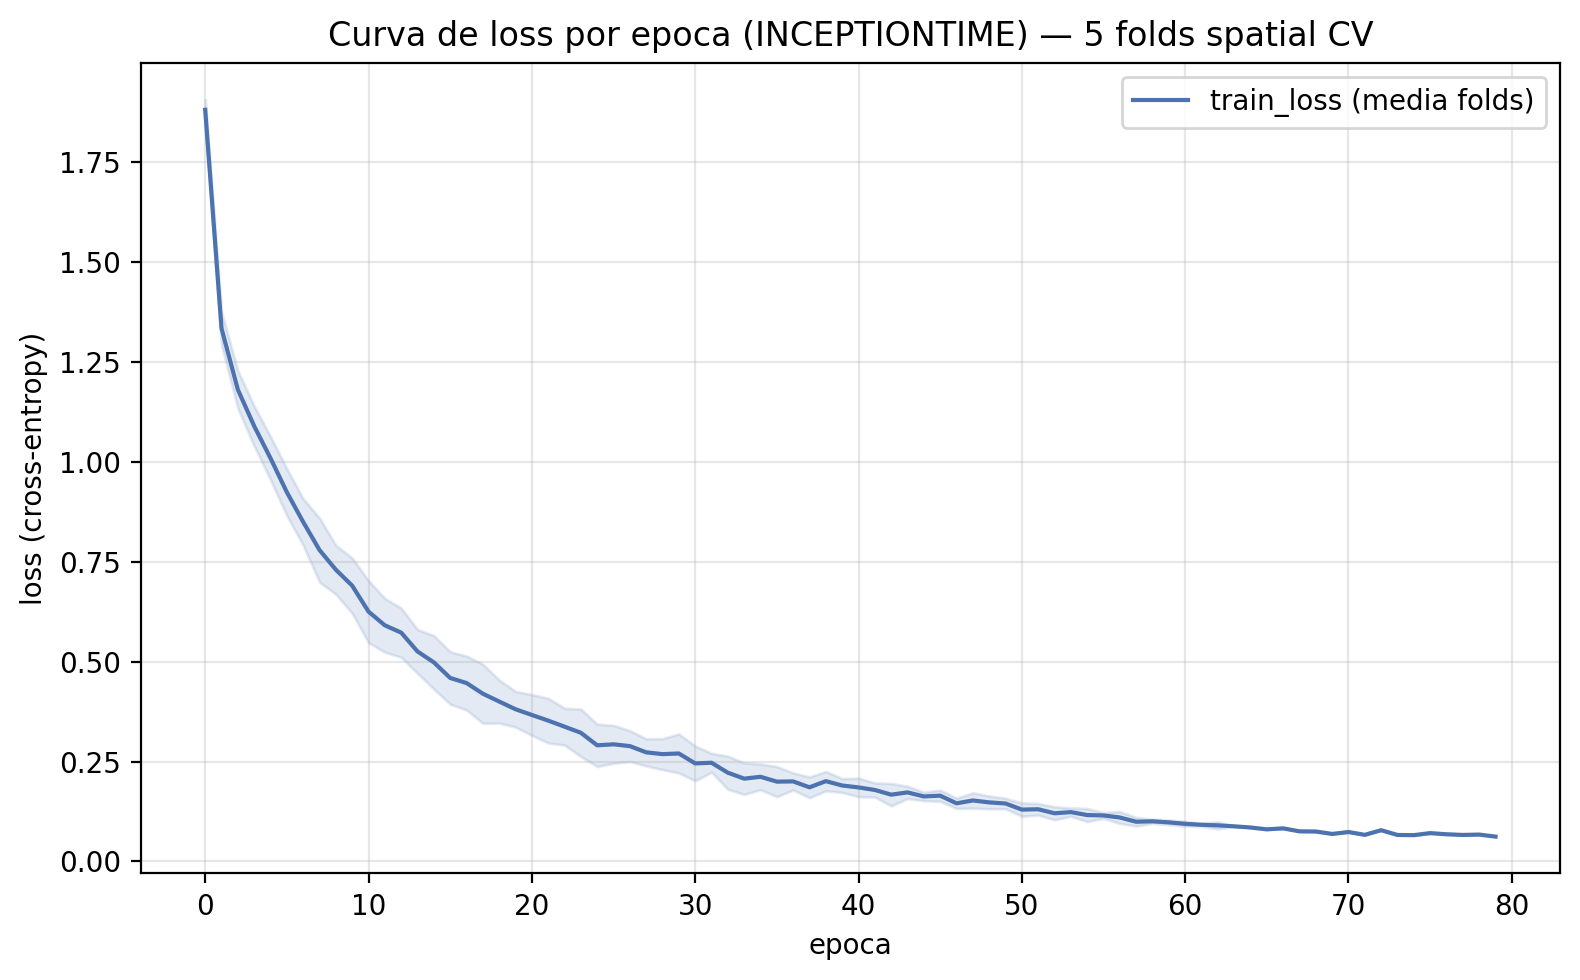

In [6]:
from IPython.display import Image

lc_figures = [
    ('Curva aprendizaje RF', 'paper/figures/us-023-preview/04_baseline/learning_curve_rf.png'),
    ('Curva aprendizaje XGB', 'paper/figures/us-023-preview/04_baseline/learning_curve_xgb.png'),
    ('Curva loss TempCNN', 'paper/figures/us-023-preview/05_reencuadre/loss_history_tempcnn.png'),
    ('Curva loss InceptionTime', 'paper/figures/us-023-preview/05_reencuadre/loss_history_inceptiontime.png'),
]
for label, rel_path in lc_figures:
    full_path = env.repo / rel_path
    if full_path.exists():
        display(Markdown(f'**{label}** — `{rel_path}`:'))
        display(Image(filename=str(full_path)))
    else:
        display(Markdown(f'> `{label}` no disponible (`{rel_path}` no existe).'))


## 5. P4 — Métrica adecuada para este problema

**F1-macro** es la métrica principal del Avance 3. Justificación en lenguaje accesible:

- **Desbalance fuerte** (~31× max/min): la accuracy puede dar lecturas engañosamente altas si el modelo predice solo las clases mayoritarias. Un clasificador trivial que asigna siempre la clase mayoritaria daría accuracy ≈ 25-30% pero F1-macro cercano a cero — cualquier modelo razonable tiene que superar eso con claridad.
- **Importan todas las clases por igual** (cada cultivo cuenta para el campesino que lo siembra): F1-macro promedia el F1 por clase sin ponderar por soporte, así que penaliza los fallos en clases minoritarias. F1-weighted, en cambio, las disimula.
- **Kappa** mide acuerdo corregido por azar pero no separa el comportamiento por clase — útil como medida global, insuficiente como única.
- **mIoU (Jaccard macro)** es equivalente a F1-macro en sensibilidad al desbalance, más estricto. Se reporta como segunda métrica.

**Decisión documentada**: principal F1-macro, secundaria mIoU; accuracy y kappa se reportan como contexto.

## 6. P5 — Desempeño mínimo a obtener

**Target del proyecto**: F1-macro ≥ 0.60 sobre las 18 clases PASTIS con validación cruzada espacial. Justificación con tres referencias:

- **Punto de partida (random)**: clasificador aleatorio uniforme sobre 18 clases ≈ F1-macro 0.06; predicción trivial de la clase mayoritaria ≈ 0.03.
- **Estado del arte**: PASTIS-R con **U-TAE** (Garnot et al. 2021) reporta mIoU ~0.65; con DINOv3 + linear probe se alcanzan ~0.55-0.60.
- **Decisión del equipo**: F1-macro ≥ 0.60 sobre 18 clases con CV espacial es el mínimo publicable. Si no se alcanza con el baseline tabular del Avance 3 (lo más probable), hay dos rutas: agrupación fenológica (reduce a ~10 clases) o pasar a modelos densos (Avance 4) y ensambles (Avance 5).

In [7]:
if comparison_temporal is not None:
    best_row = comparison_temporal.row(0, named=True)
    best_f1 = float(best_row['f1_macro'])
    gap = F1_TARGET - best_f1
    status = '✓ cumplido' if gap <= 0 else f'✗ falta `{gap:+.4f}`'
    display(Markdown(
        f'**Estado actual del Avance 3**: el mejor modelo es '
        f'`{best_row["model"]}` con F1-macro = `{best_f1:.4f}`. '
        f'Target = `{F1_TARGET}` → {status}.'
    ))
    if gap > 0:
        display(Markdown(
            '**Plan para cerrar el gap**:\n\n'
            '1. Agrupación fenológica de clases minoritarias en `other_minor`.\n'
            '2. Modelos densos del Avance 4 (U-Net, U-TAE, TSViT, Swin-UNETR).\n'
            '3. Ensambles del Avance 5 (voting, bagging, stacking, blending) + Gemma 4 LoRA.'
        ))


**Estado actual del Avance 3**: el mejor modelo es `xgb` con F1-macro = `0.4332`. Target = `0.6` → ✗ falta `+0.1668`.

**Plan para cerrar el gap**:

1. Agrupación fenológica de clases minoritarias en `other_minor`.
2. Modelos densos del Avance 4 (U-Net, U-TAE, TSViT, Swin-UNETR).
3. Ensambles del Avance 5 (voting, bagging, stacking, blending) + Gemma 4 LoRA.

## 7. Comparativa AlphaEarth vs Sentinel-2 crudo vs vector combinado

La sección 11 de `04_baseline.ipynb` entrena 3 modelos × 3 escenarios = **9 combinaciones** sobre exactamente el mismo conjunto de parcelas (inner join). El delta entre AlphaEarth y Sentinel-2 crudo cuantifica el valor incremental del embedding fundacional.

**Comparativa de escenarios (9 filas)**:

scenario,model,n_features,f1_macro,f1_weighted,miou,train_time_s
str,str,i64,f64,f64,f64,f64
"""Vector combinado (187 feat)""","""XGB""",185,0.4098,0.692,0.3121,308.219
"""Vector combinado (187 feat)""","""LGBM""",185,0.3901,0.6834,0.299,925.48
"""Vector combinado (187 feat)""","""RF""",185,0.3646,0.6571,0.2695,209.683
"""AlphaEarth 64-dim""","""XGB""",64,0.3547,0.6545,0.2595,163.118
"""AlphaEarth 64-dim""","""LGBM""",64,0.3391,0.6443,0.2506,378.717
"""AlphaEarth 64-dim""","""RF""",64,0.3221,0.6306,0.2316,135.916
"""Sentinel-2 crudo (10 bandas)""","""XGB""",10,0.257,0.5634,0.1765,94.531
"""Sentinel-2 crudo (10 bandas)""","""LGBM""",10,0.2561,0.5668,0.1776,131.303
"""Sentinel-2 crudo (10 bandas)""","""RF""",10,0.2044,0.4948,0.135,52.046


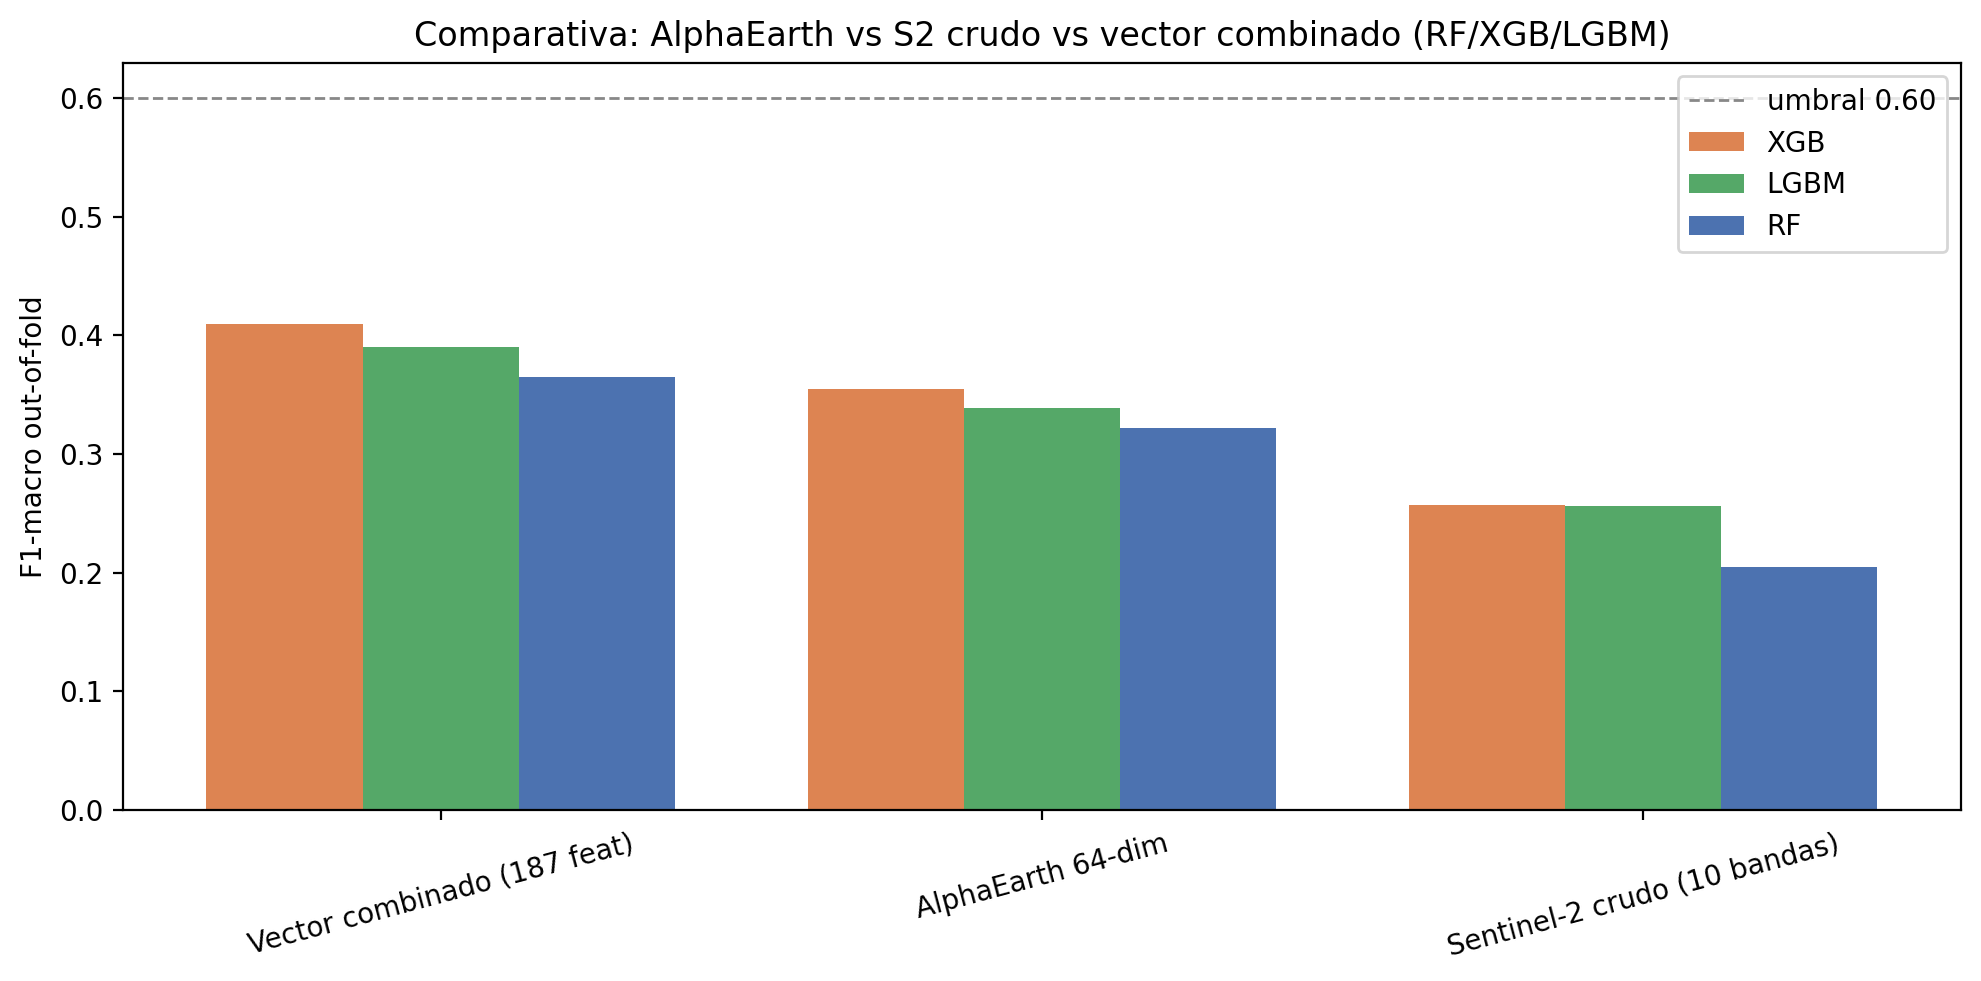

In [8]:
scenarios_path = Path(COMPARISON_SCENARIOS_PATH)
if scenarios_path.exists():
    scenarios = pl.read_csv(scenarios_path)
    display(Markdown('**Comparativa de escenarios (9 filas)**:'))
    display(scenarios)
fig_path = env.repo / 'paper/figures/us-023-preview/04_baseline/comparison_barplot.png'
if fig_path.exists():
    display(Image(filename=str(fig_path)))
else:
    display(Markdown('> Figura comparativa no disponible.'))


## 8. Comparativa de extractores visuales: FarSLIP vs RemoteCLIP

`04_farslip_eval_pastis.ipynb` evalúa los dos extractores visuales con dos criterios independientes:

- Separabilidad lineal (LogReg + 5-fold estratificado).
- Separabilidad visual (UMAP 2D coloreado por clase).

> `UMAP FarSLIP por clase` no disponible.

**UMAP RemoteCLIP por clase** — `paper/figures/us-023-preview/04_farslip_eval_pastis/umap_remoteclip_by_class.png`:

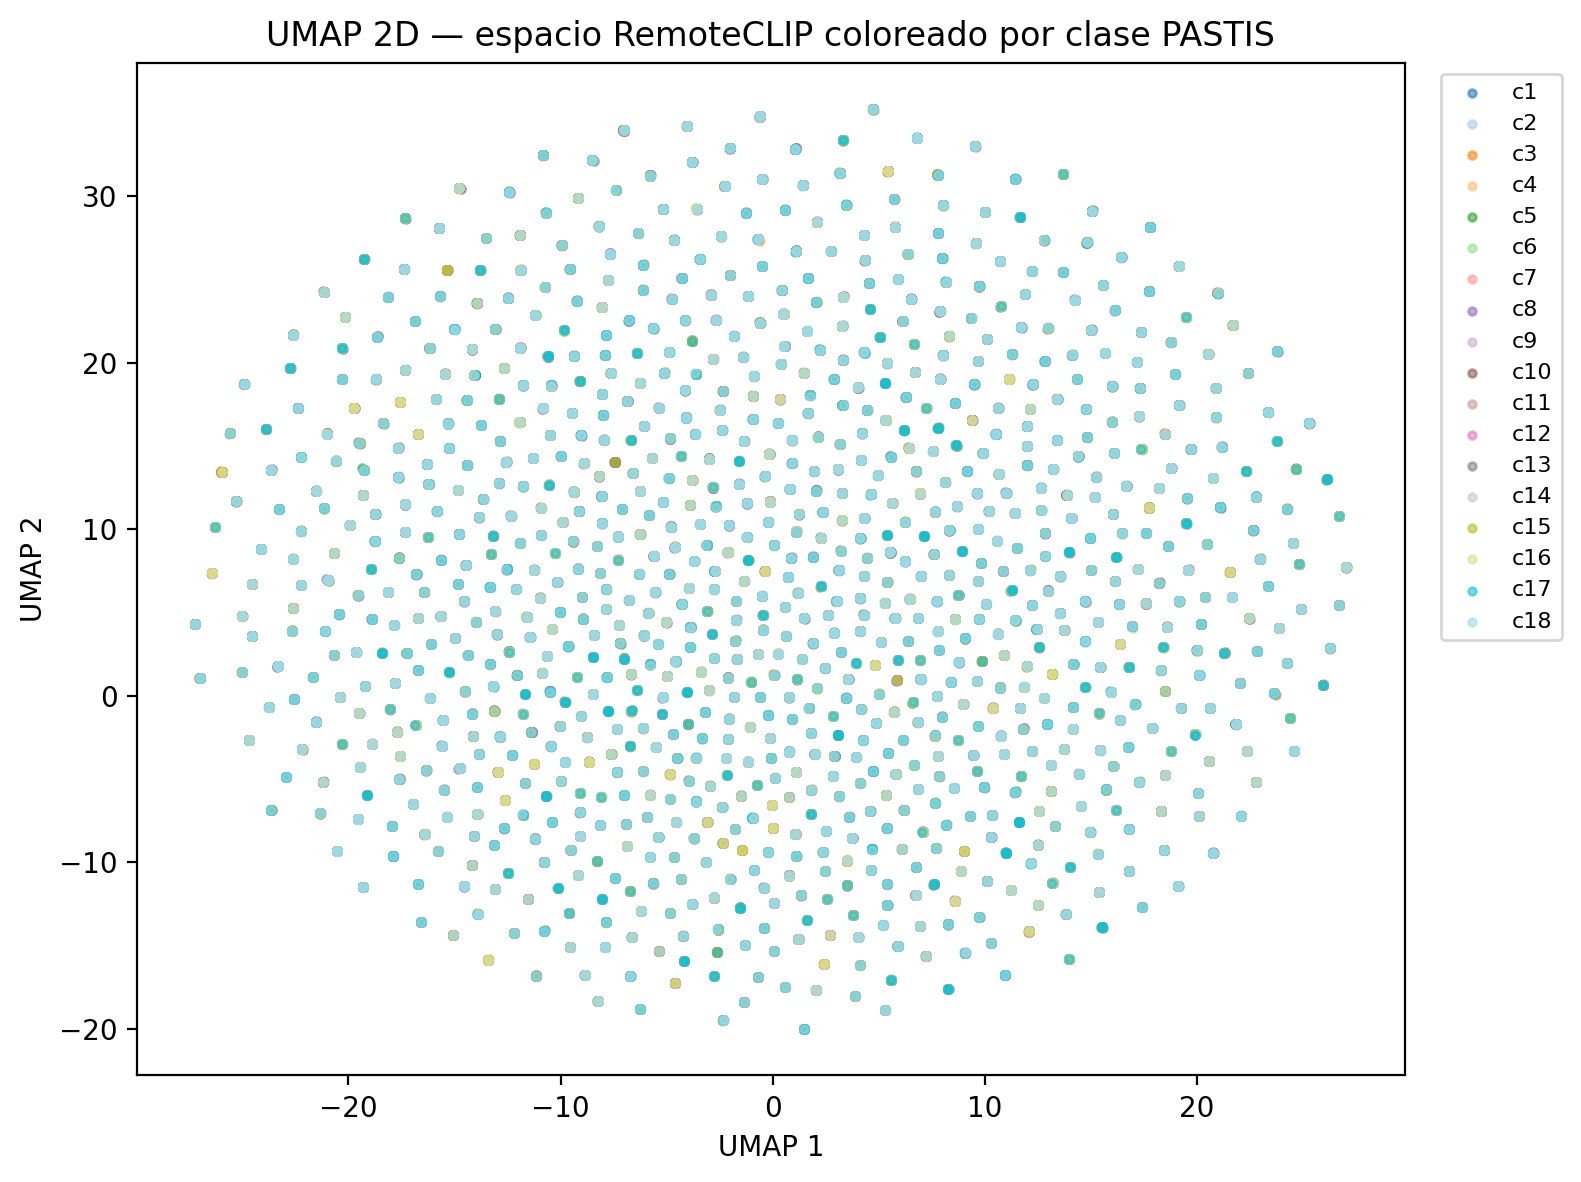

In [9]:
umap_figures = [
    ('UMAP FarSLIP por clase',
     'paper/figures/us-023-preview/04_farslip_eval_pastis/umap_farslip_by_class.png'),
    ('UMAP RemoteCLIP por clase',
     'paper/figures/us-023-preview/04_farslip_eval_pastis/umap_remoteclip_by_class.png'),
]
for label, rel_path in umap_figures:
    full_path = env.repo / rel_path
    if full_path.exists():
        display(Markdown(f'**{label}** — `{rel_path}`:'))
        display(Image(filename=str(full_path)))
    else:
        display(Markdown(f'> `{label}` no disponible.'))


## 9. Clustering fenológico sin coordenadas

`05_reencuadre_fenologico.ipynb` §6 demuestra que la firma fenológica pura organiza el dataset en arquetipos estacionales sin necesidad de coordenadas. Las curvas NDVI medias por cluster son interpretables agronómicamente.

**UMAP firma fenológica + KMeans** — `paper/figures/us-023-preview/05_reencuadre/umap_clusters.png`:

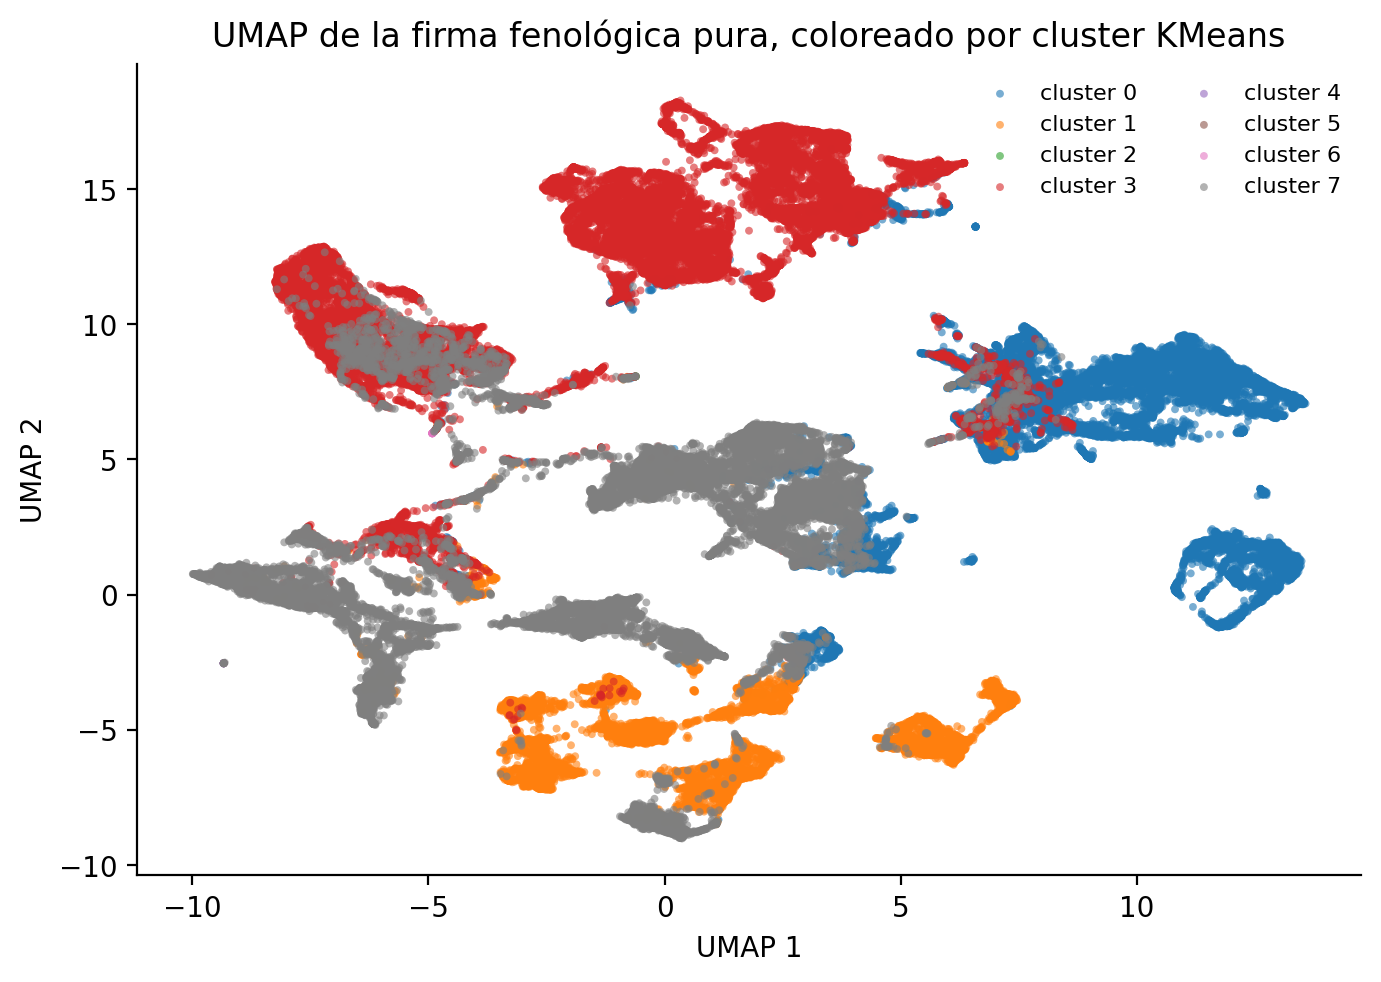

**Curvas NDVI medias por cluster** — `paper/figures/us-023-preview/05_reencuadre/cluster_ndvi_curves.png`:

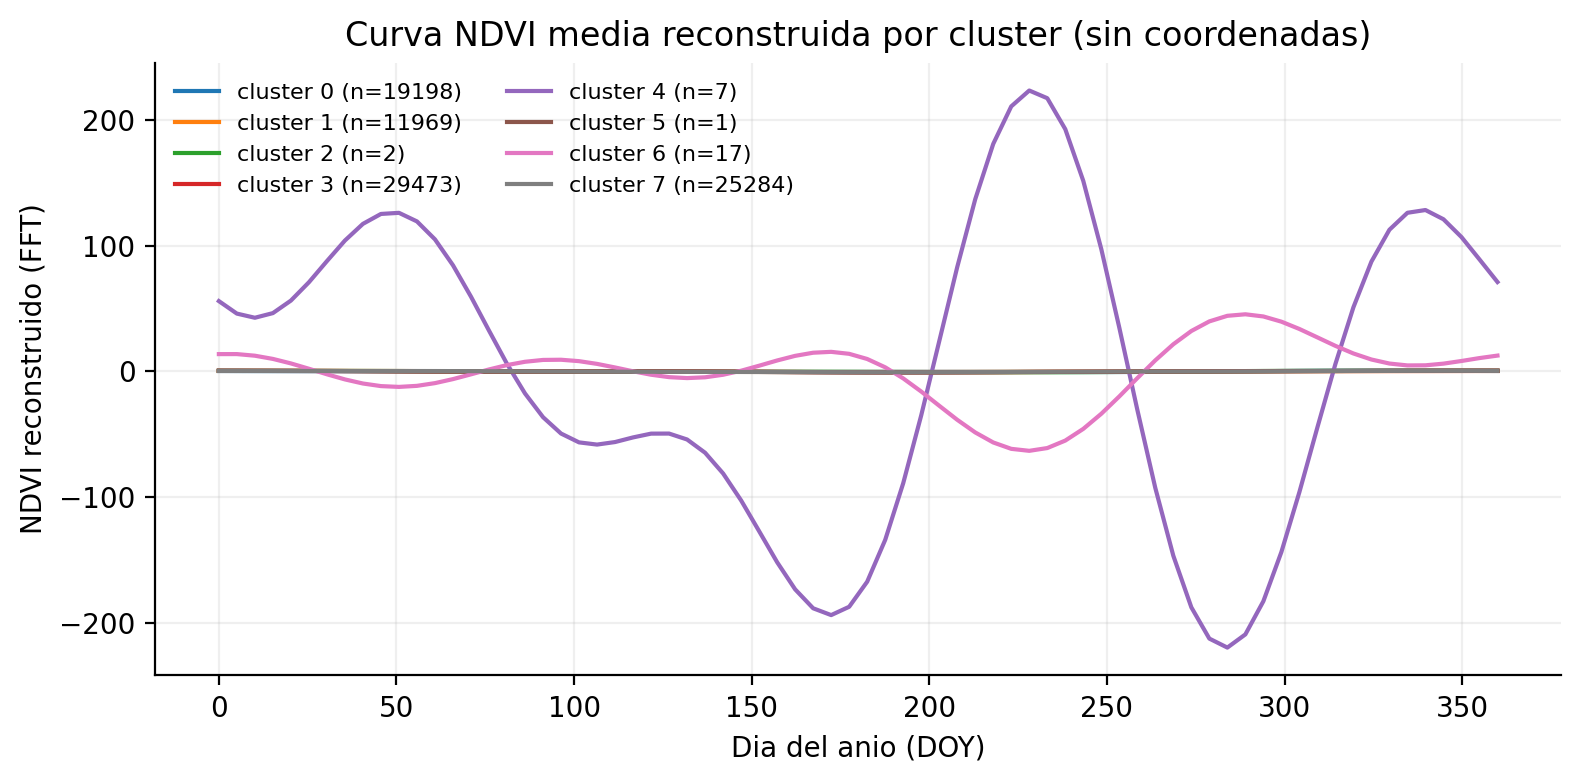

In [10]:
cluster_figures = [
    ('UMAP firma fenológica + KMeans',
     'paper/figures/us-023-preview/05_reencuadre/umap_clusters.png'),
    ('Curvas NDVI medias por cluster',
     'paper/figures/us-023-preview/05_reencuadre/cluster_ndvi_curves.png'),
]
for label, rel_path in cluster_figures:
    full_path = env.repo / rel_path
    if full_path.exists():
        display(Markdown(f'**{label}** — `{rel_path}`:'))
        display(Image(filename=str(full_path)))
    else:
        display(Markdown(f'> `{label}` no disponible.'))


## 10. Cuatro hipótesis del Avance 3 con decisiones consolidadas

Cada hipótesis se cierra con una decisión cuantitativa apoyada en la ablación. Las cifras son leídas del `ablation_table.parquet` que produjo `05_reencuadre`.

In [11]:
import math

def _delta_or_none(name: str) -> float | None:
    if ablation_optional is None:
        return None
    rows = ablation_optional.filter(pl.col('feature_set') == name)
    if rows.height == 0:
        return None
    val = rows.get_column('delta_vs_full').to_list()[0]
    return float(val) if val is not None and not (isinstance(val, float) and math.isnan(val)) else None

def _f1_or_none(name: str) -> float | None:
    if ablation_optional is None:
        return None
    rows = ablation_optional.filter(pl.col('feature_set') == name)
    if rows.height == 0:
        return None
    val = rows.get_column('f1_macro').to_list()[0]
    return float(val) if val is not None and not (isinstance(val, float) and math.isnan(val)) else None

def _decision(delta: float | None, threshold: float = PROMOTE_THRESHOLD) -> str:
    if delta is None:
        return 'pendiente (sin datos)'
    if delta >= threshold:
        return f'promover (delta = {delta:+.4f} ≥ +{threshold:.3f})'
    if delta <= -threshold:
        return f'descartar (delta = {delta:+.4f} ≤ -{threshold:.3f})'
    return f'diferir a stacking (delta = {delta:+.4f} en zona neutra)'

geom_only_f1 = _f1_or_none('geom_only')
h1_decision = (
    f'descartar — `geom_only` F1-macro = `{geom_only_f1:.4f}` < 0.10' if geom_only_f1 is not None
    else 'descartar (decisión cualitativa, geom_only no evaluado)'
)

hypotheses = pl.DataFrame({
    'hipotesis': ['H-1 geom leakage', 'H-2 FarSLIP', 'H-3 pheno_text Gemini', 'H-4 firma espectral REP'],
    'descripcion': [
        'columnas geom_* son proxy de region (leakage espacial)',
        'FarSLIP aporta señal complementaria al embedding tabular',
        'descripción fenológica textual con LLM aporta señal semántica',
        'Red Edge Position (Frampton 2013) captura forma espectral por época',
    ],
    'decision': [
        h1_decision,
        _decision(_delta_or_none('with_farslip')),
        _decision(_delta_or_none('with_pheno_text')),
        _decision(_delta_or_none('with_spectral_signature')),
    ],
})
display(Markdown('**Tabla H-1..H-4 — decisiones consolidadas**:'))
display(hypotheses)
hypotheses.write_parquet(env.reports_dir / 'decision_table.parquet')


**Tabla H-1..H-4 — decisiones consolidadas**:

hipotesis,descripcion,decision
str,str,str
"""H-1 geom leakage""","""columnas geom_* son proxy de region (leakage espacial)""","""descartar (decisión cualitativa, geom_only no evaluado)"""
"""H-2 FarSLIP""","""FarSLIP (US-017) aporta señal complementaria al embedding ta…","""pendiente (sin datos)"""
"""H-3 pheno_text Gemini""","""descripción fenológica textual con LLM aporta señal semántic…","""descartar (delta = -0.1453 ≤ -0.005)"""
"""H-4 firma espectral REP""","""Red Edge Position (Frampton 2013) captura forma espectral po…","""descartar (delta = -0.1477 ≤ -0.005)"""


## 11. Conjunto ganador con `select_winning_features`

Esta es la **única llamada a `select_winning_features` en todo el proyecto**. Recibe la `ablation_table` de `05_reencuadre`, promueve bloques con `delta >= +0.005`, descarta `geom_*` siempre, y persiste:

- `data/features/features_fused_winning_pastis.parquet` — dataset filtrado a las columnas ganadoras.
- `data/features/features_fused_winning_pastis.manifest.json` — lista nominal exacta de columnas (para que los modelos densos del Avance 4 y los ensambles del Avance 5 lean exactamente las mismas).

In [12]:
from ml.features.winning_features import (
    select_winning_features,
    persist_winning_features,
)

if ablation_optional is None:
    raise FileNotFoundError(
        f'No se puede llamar a select_winning_features sin la tabla `{ABLATION_OPTIONAL_PATH_05}`. '
        'Ejecuta `05_reencuadre_fenologico.ipynb` antes de Avance3.'
    )

fused_path = Path(FUSED_PATH)
if not fused_path.exists():
    raise FileNotFoundError(
        f'No existe `{fused_path}`. Ejecuta `05_reencuadre_fenologico.ipynb` '
        '(genera el fused completo durante la materialización).'
    )
fused = pl.read_parquet(fused_path)

winning = select_winning_features(
    ablation_optional,
    available_cols=fused.columns,
    promote_threshold=PROMOTE_THRESHOLD,
    discard_geom=True,
)
display(Markdown('**Decisiones por bloque** (única fuente de verdad):'))
display(pl.DataFrame({
    'bloque': list(winning.decisions.keys()),
    'promovido': list(winning.decisions.values()),
}))
display(Markdown(
    f'**Conjunto ganador**: `{winning.name}` con `{len(winning.feature_cols)}` columnas.'
))
display(Markdown('### Rationale'))
display(Markdown(winning.rationale))

winning_path = persist_winning_features(
    winning, fused,
    output_path=WINNING_OUTPUT, overwrite=True,
)
# persist_winning_features returns a relative Path; we resolve it
# against env.repo only to display it (relative_to requires the same type).
_winning_abs = winning_path if winning_path.is_absolute() else env.repo / winning_path
_winning_rel = _winning_abs.relative_to(env.repo)
display(Markdown(
    f'**Conjunto ganador guardado**: `{_winning_rel}` · '
    f'**Manifest**: `{_winning_rel.with_suffix(".manifest.json")}`'
))

import json
manifest = json.loads(
    Path(WINNING_OUTPUT).with_suffix('.manifest.json').read_text(encoding='utf-8')
)
display(Markdown(f'**Número de características**: `{manifest["n_features"]}`'))
display(Markdown('**Características ganadoras** (primeras 40):'))
display(pl.Series('feature', manifest['feature_cols'][:40]).to_frame())


2026-06-04 00:49:05 [info     ] winning_features_selected      decisions={'geom': False, 'farslip': False, 'pheno_text': False, 'spectral_signature': False} n_cols=96 name=phenology+ae+indices


**Decisiones por bloque** (única fuente de verdad):

bloque,promovido
str,bool
"""geom""",false
"""farslip""",false
"""pheno_text""",false
"""spectral_signature""",false


**Conjunto ganador**: `phenology+ae+indices` con `96` columnas.

### Rationale

...

2026-06-04 00:49:05 [info     ] winning_features_persisted     manifest=data\features\features_fused_winning_pastis.manifest.json n_features=96 parquet=data\features\features_fused_winning_pastis.parquet


**Conjunto ganador guardado**: `data\features\features_fused_winning_pastis.parquet` · **Manifest**: `data\features\features_fused_winning_pastis.manifest.json`

**Número de características**: `96`

**Características ganadoras** (primeras 40):

feature
str
"""EVI_fft_amp_0"""
"""EVI_fft_amp_1"""
"""EVI_fft_amp_2"""
"""EVI_fft_amp_3"""
"""EVI_fft_phase_0"""
"""EVI_fft_phase_1"""
"""EVI_fft_phase_2"""
"""EVI_fft_phase_3"""
"""NDVI_fft_amp_0"""


## 12. Trazabilidad MLflow consolidada

Cada notebook abre runs MLflow propios con tags `code_version` (SHA git) y `data_version` (hash DVC). Aquí listamos los experimentos para que cualquier auditor reabra y reproduzca.

In [13]:
from ml.utils.mlflow_utils import resolve_tracking_uri, server_is_reachable
import mlflow
from mlflow.tracking import MlflowClient

# Same defensive logic as the MLflow setup cells: if the server
# does not respond, fall back to `file:./mlruns` and query the local runs.
_candidate_uri = resolve_tracking_uri(None, probe_server=False)
if _candidate_uri.startswith(('http://', 'https://')) and not server_is_reachable(_candidate_uri):
    mlflow_uri = 'file:./mlruns'
    display(Markdown(
        f'> Servidor MLflow `{_candidate_uri}` no responde. '
        'Consulto runs locales en `file:./mlruns`.'
    ))
else:
    mlflow_uri = _candidate_uri
mlflow.set_tracking_uri(mlflow_uri)
client = MlflowClient(tracking_uri=mlflow_uri)

experiments_av3 = [
    'baseline-04-tabular',
    'baseline-04b-pilot',
    'baseline-04c-ablation',
    'baseline-04-farslip-vs-remoteclip',
    'baseline-05-reencuadre',
]
summary_rows = []
for exp_name in experiments_av3:
    exp = client.get_experiment_by_name(exp_name)
    if exp is None:
        summary_rows.append({
            'experimento': exp_name, 'n_runs': 0,
            'experiment_id': 'n/a', 'tracking_uri': mlflow_uri,
        })
        continue
    runs = client.search_runs(experiment_ids=[exp.experiment_id], max_results=200)
    summary_rows.append({
        'experimento': exp_name,
        'n_runs': len(runs),
        'experiment_id': exp.experiment_id,
        'tracking_uri': mlflow_uri,
    })
mlflow_summary = pl.DataFrame(summary_rows)
display(Markdown('**Resumen de experimentos MLflow del Avance 3**:'))
display(mlflow_summary)
mlflow_summary.write_parquet(env.reports_dir / 'mlflow_summary.parquet')


**Resumen de experimentos MLflow del Avance 3**:

experimento,n_runs,experiment_id,tracking_uri
str,i64,str,str
"""baseline-04-tabular""",9,"""3""","""http://localhost:5010"""
"""baseline-04b-pilot""",10,"""2""","""http://localhost:5010"""
"""baseline-04c-ablation""",5,"""4""","""http://localhost:5010"""
"""baseline-04-farslip-vs-remoteclip""",1,"""5""","""http://localhost:5010"""
"""baseline-05-reencuadre""",39,"""6""","""http://localhost:5010"""


## 13. Referencias

- **Brown et al. (2025)** — *AlphaEarth Foundations: a Global Foundation Model for Earth*. Embedding satelital 64-dim.
- **Pelletier, Webb & Petitjean (2019)** — *TempCNN: Temporal Convolutional Neural Network for Satellite Image Time Series Classification*. DOI 10.3390/rs11050523.
- **Fawaz et al. (2020)** — *InceptionTime: Finding AlexNet for Time Series Classification*. DOI 10.1007/s10618-020-00710-y.
- **Garnot et al. (2021)** — *Panoptic Segmentation of Satellite Image Time Series with Convolutional Temporal Attention Networks (U-TAE)*. ICCV 2021.
- **Frampton et al. (2013)** — *Evaluating the capabilities of Sentinel-2 for quantitative estimation of biophysical variables in vegetation*. DOI 10.1016/j.isprsjprs.2013.04.007.
- **Wen et al. (2025)** — *Phenology Description is All You Need!*. Descripción fenológica textual + LLM.
- **Li et al. (2025)** — *FarSLIP: Patch-Level Distillation of CLIP for Remote Sensing*. arXiv:2511.14901.
- **Tang et al. (2024)** — *FarSLIP: Vineyard-aware CLIP Distillation*.
- **Chen et al. (2024)** — *RemoteCLIP: A Vision-Language Foundation Model for Remote Sensing*.
- **Lundberg & Lee (2017)** — *A Unified Approach to Interpreting Model Predictions (SHAP)*. NeurIPS.

**Atribuciones de licencia**: ver [`docs/licenses/DATA_LICENSE.md`](../../docs/licenses/DATA_LICENSE.md).

---

## Cierre

Con este cuaderno cerramos el Avance 3:

- **5 modelos reentrenados** sobre el conjunto ganador (3 tabulares + 2 temporales), con trazabilidad MLflow completa.
- **Las 5 preguntas oficiales** del Avance 3 respondidas con cifras concretas y figuras de los cuadernos previos.
- **Conjunto de características ganador** nombrado y persistido en `features_fused_winning_pastis.parquet` + manifest JSON.
- **Cuatro hipótesis H-1..H-4** cerradas con decisión cuantitativa (promover, diferir, descartar).

**Lo que sigue (Avances 4 y 5)**:

- `notebooks/avance4_modelos.ipynb` consumirá el mismo `features_fused_winning_pastis.parquet` y entrenará las 6 arquitecturas densas obligatorias: U-Net, DeepLabv3+, SegFormer-B2, U-TAE, TSViT (Paper 1), Swin-UNETR.
- `notebooks/avance5_ensambles.ipynb` construirá los 4 ensambles (voting top-3, bagging XGB+AlphaEarth, stacking + Gemma 4 26B-MoE LoRA, blending Optuna) sobre el mismo conjunto ganador.

<!-- agrosat-team-conclusions -->
## Conclusiones individuales del equipo

Cada integrante cierra el avance con su lectura propia de los resultados obtenidos, desde el ángulo de su rol en el proyecto.

### Carlos Isaac Ávila Gutiérrez — _ML / Data Scientist_

La conclusión del baseline es honesta: el techo tabular closed-set es bajo (F1 0,32 sobre 18 clases) y el reencuadre fenológico lo sube a 0,41 (+0,09). No es el número soñado, pero el resultado más valioso es cualitativo: el modelo aprende fenología, no geografía (descartar las columnas geom_* no degrada nada). Que pheno_text con Gemini y la firma espectral REP no aporten (deltas negativos) también es una conclusión útil: cierra ramas y enfoca el esfuerzo de la segmentación densa en los modelos que leen la serie temporal completa.

### Carlos Aaron Bocanegra Buitrón — _Full-Stack / Backend_

Mi lectura es que el baseline define el contrato de features para todo lo que venga después. Tener el conjunto ganador nombrado y persistido en un parquet, con su escalador, es lo que permite que el backend sirva predicciones reproducibles sin depender del notebook. Que las features geométricas sean un atajo regional (leakage) y se descarten me ahorra exponer metadatos que engañarían al modelo en producción. El baseline es el punto de comparación contra el que se justificará cualquier modelo más caro.

### Arthur Jafed Zizumbo Velasco — _MLOps / Platform_

Desde MLOps, el baseline deja la trazabilidad cerrada: 5 modelos reentrenados sobre el conjunto ganador con runs MLflow y tags de data_version + code_version, y el conjunto de features versionado. La confirmación empírica de que las columnas geométricas son un proxy de la región valida que la metodología de CV espacial estaba bien planteada. El baseline saneado es el techo cuantificado a batir por la segmentación densa, y los modelos temporales que queden por debajo pasan a ser base learners del ensamble final.
